



Epoch 1/10


782/782 [==============================] - 7s 8ms/step - loss: 1.5440 - accuracy: 0.4370 - val_loss: 1.3779 - val_accuracy: 0.5087
Epoch 2/10
782/782 [==============================] - 6s 8ms/step - loss: 1.2034 - accuracy: 0.5731 - val_loss: 1.0995 - val_accuracy: 0.6105
Epoch 3/10
782/782 [==============================] - 6s 8ms/step - loss: 1.0370 - accuracy: 0.6369 - val_loss: 1.0257 - val_accuracy: 0.6468
Epoch 4/10
782/782 [==============================] - 6s 7ms/step - loss: 0.9232 - accuracy: 0.6762 - val_loss: 0.9552 - val_accuracy: 0.6654
Epoch 5/10
782/782 [==============================] - 6s 7ms/step - loss: 0.8462 - accuracy: 0.7050 - val_loss: 0.8832 - val_accuracy: 0.6907
Epoch 6/10
782/782 [==============================] - 6s 7ms/step - loss: 0.7835 - accuracy: 0.7265 - val_loss: 0.8471 - val_accuracy: 0.7072
Epoch 7/10
782/782 [==============================] - 6s 7ms/step - loss: 0.7352 - accuracy: 0.7433 - val_loss: 0.8751 - val_accuracy: 0.7017


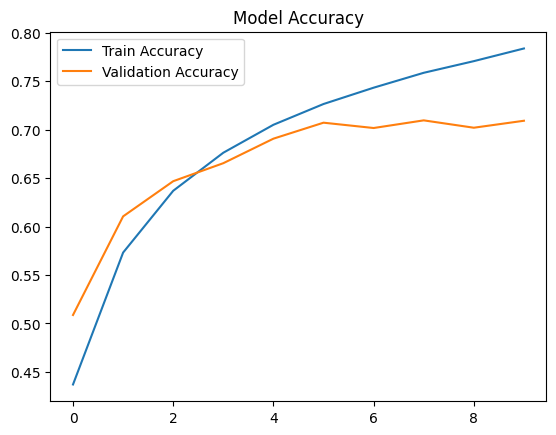

313/313 [==============================] - 1s 2ms/step


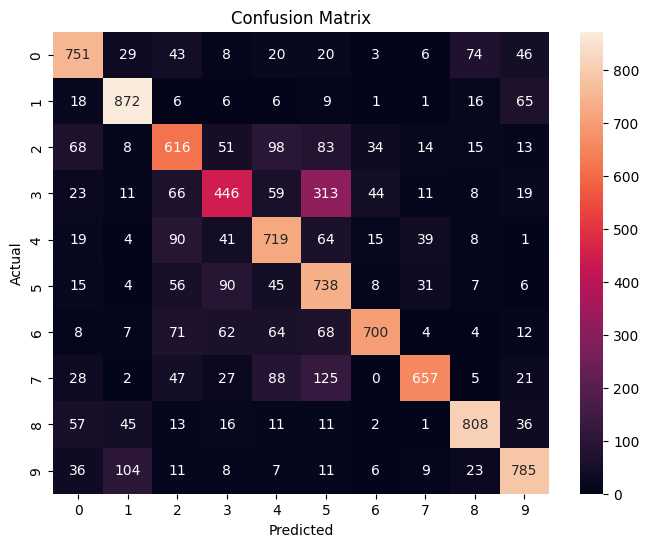

              precision    recall  f1-score   support

           0       0.73      0.75      0.74      1000
           1       0.80      0.87      0.84      1000
           2       0.60      0.62      0.61      1000
           3       0.59      0.45      0.51      1000
           4       0.64      0.72      0.68      1000
           5       0.51      0.74      0.60      1000
           6       0.86      0.70      0.77      1000
           7       0.85      0.66      0.74      1000
           8       0.83      0.81      0.82      1000
           9       0.78      0.79      0.78      1000

    accuracy                           0.71     10000
   macro avg       0.72      0.71      0.71     10000
weighted avg       0.72      0.71      0.71     10000



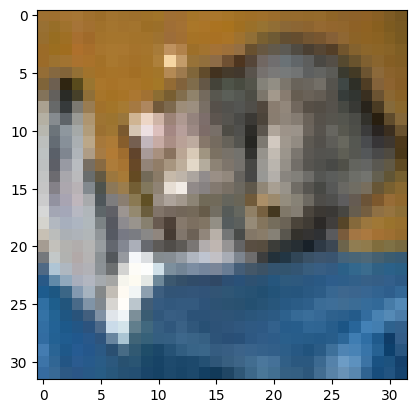

1/1 [==============================] - 0s 20ms/step
Predicted Class: cat


In [1]:
# ================================
# 1. Import Libraries
# ================================
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# ================================
# 2. Load Dataset
# ================================
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

# ================================
# 3. Normalize Images
# ================================
X_train = X_train / 255.0
X_test = X_test / 255.0

# ================================
# 4. One-Hot Encoding
# ================================
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# ================================
# 5. Define CNN Model
# ================================
model = models.Sequential()

# First Convolution Block
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
model.add(layers.MaxPooling2D((2,2)))

# Second Convolution Block
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

# Third Convolution Block
model.add(layers.Conv2D(64, (3,3), activation='relu'))

# Flatten Layer
model.add(layers.Flatten())

# Fully Connected Layer
model.add(layers.Dense(64, activation='relu'))

# Output Layer
model.add(layers.Dense(10, activation='softmax'))

# ================================
# 6. Compile Model
# ================================
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# ================================
# 7. Train Model
# ================================
history = model.fit(X_train, y_train,
                    epochs=10,
                    batch_size=64,
                    validation_data=(X_test, y_test))

# ================================
# 8. Evaluate Model
# ================================
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)

# ================================
# 9. Plot Accuracy Graph
# ================================
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.show()

# ================================
# 10. Confusion Matrix
# ================================
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ================================
# 11. Classification Report
# ================================
print(classification_report(y_true, y_pred_classes))

# ================================
# 12. Predict Single Image
# ================================
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

plt.imshow(X_test[0])
plt.show()

prediction = model.predict(np.expand_dims(X_test[0], axis=0))
print("Predicted Class:", class_names[np.argmax(prediction)])